In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, binomtest, norm
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier
import shap

pd.set_option("display.width", 120)
np.random.seed(42)

C:\Users\mayar\OneDrive\Desktop\ATUTEB 2026 (IDA vs BTM)\crispy-xylophone\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ===== Chargement unique des donnees (une seule fois dans tout le notebook) =====
DATA_PATH = "data/base apres nettoyage.xlsx"

data = pd.read_excel(DATA_PATH)
data.columns = data.columns.str.strip()

# Le fichier Excel contient, en plus des lignes patients, un petit tableau
# recapitulatif construit a la main sur quelques lignes en bas de la feuille
# (colonnes HBG/HCT/VGM/TCMH polluees par du texte comme "BTM (n=27)",
# "Age (years)", etc.). On force ces colonnes hematologiques en numerique :
# tout texte residuel devient NaN, et ces lignes seront naturellement exclues
# plus loin (Diagnostic sera NaN pour elles).
NUMERIC_COLUMNS = [c for c in data.columns if c not in ("sexe", "Diagnostic")]
for col in NUMERIC_COLUMNS:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Nettoyage du texte AVANT tout mapping : le fichier contient des variantes
# (espace finale, casse differente) qui doivent etre normalisees avant de mapper
# vers la cible, sinon certains patients recoivent silencieusement un target manquant.
# On ne touche pas aux vrais NaN (sinon astype(str) les transformerait en "nan").
data["Diagnostic"] = data["Diagnostic"].apply(lambda x: str(x).strip().lower() if pd.notna(x) else x)
data["sexe"] = data["sexe"].apply(lambda x: str(x).strip().lower() if pd.notna(x) else x)

print("Valeurs uniques de Diagnostic apres nettoyage :")
print(data["Diagnostic"].value_counts())

DIAGNOSIS_MAP = {
    "anemie ferriprive": ("IDA", 0),
    "b thal mineure": ("BTM", 1),
}

data["label"] = data["Diagnostic"].map(lambda d: DIAGNOSIS_MAP.get(d, (None, None))[0])
data["target"] = data["Diagnostic"].map(lambda d: DIAGNOSIS_MAP.get(d, (None, None))[1])

excluded = data[data["label"].isna()]
if len(excluded):
    print(f"\n{len(excluded)} ligne(s) hors cohorte IDA/BTM exclue(s) (diagnostic non reconnu) :")
    print(excluded["Diagnostic"].value_counts())

data = data.dropna(subset=["target"]).copy()
data["target"] = data["target"].astype(int)

print(f"\nCohorte finale : {len(data)} patients")
print(data["label"].value_counts())

Valeurs uniques de Diagnostic apres nettoyage :
Diagnostic
anemie ferriprive    189
b thal mineure        27
Name: count, dtype: int64

9 ligne(s) hors cohorte IDA/BTM exclue(s) (diagnostic non reconnu) :
Series([], Name: count, dtype: int64)

Cohorte finale : 216 patients
label
IDA    189
BTM     27
Name: count, dtype: int64


In [3]:
# ===== TABLE I : CARACTERISTIQUES DEMOGRAPHIQUES =====
btm = data[data["label"] == "BTM"]
ida = data[data["label"] == "IDA"]

age_btm_mean, age_btm_sd = btm["age"].mean(), btm["age"].std()
age_ida_mean, age_ida_sd = ida["age"].mean(), ida["age"].std()
_, p_age = mannwhitneyu(btm["age"].dropna(), ida["age"].dropna())


def sex_counts(df):
    total = len(df)
    female = int((df["sexe"] == "f").sum())
    male = int((df["sexe"] == "h").sum())
    return female, male, total


btm_f, btm_m, btm_n = sex_counts(btm)
ida_f, ida_m, ida_n = sex_counts(ida)

contingency = pd.crosstab(data["label"], data["sexe"])
_, p_sex = stats.fisher_exact(contingency.values)

table1 = pd.DataFrame({
    "": ["Age (years)", "Sexe - Female n(%)", "Sexe - Male n(%)"],
    f"BTM (n={btm_n})": [
        f"{age_btm_mean:.1f} +/- {age_btm_sd:.1f}",
        f"{btm_f} ({btm_f/btm_n*100:.1f}%)",
        f"{btm_m} ({btm_m/btm_n*100:.1f}%)",
    ],
    f"IDA (n={ida_n})": [
        f"{age_ida_mean:.1f} +/- {age_ida_sd:.1f}",
        f"{ida_f} ({ida_f/ida_n*100:.1f}%)",
        f"{ida_m} ({ida_m/ida_n*100:.1f}%)",
    ],
    "p-value": [f"{p_age:.3f}", f"{p_sex:.3f}", ""],
})
print("Test statistique : Mann-Whitney U (age) et Fisher exact (sexe)\n")
print(table1.to_string(index=False))

Test statistique : Mann-Whitney U (age) et Fisher exact (sexe)

                      BTM (n=27)   IDA (n=189) p-value
       Age (years) 48.5 +/- 13.6 43.8 +/- 15.3   0.067
Sexe - Female n(%)    20 (74.1%)   163 (86.2%)   0.147
  Sexe - Male n(%)     7 (25.9%)    26 (13.8%)        


In [4]:
# ===== TABLE II : COMPARAISON DES PARAMETRES HEMATOLOGIQUES =====
HEMATO_VARS = [
    "GR", "HBG", "HCT", "VGM", "TCMH", "CCMH",
    "PLQ", "IDR-SD", "IDR-CV", "IDP", "VPM", "P-RGC", "PCT",
    "NEUT", "LYMPH", "MONO", "EO", "BASO",
    "RET pourcentage", "retic absolue",
    "IRF", "LFR", "MFR", "HFR",
]

UNIT_CONVERSIONS = {
    "PLQ": 1e3, "NEUT": 1e3, "LYMPH": 1e3, "MONO": 1e3, "EO": 1e3, "BASO": 1e3,
    "retic absolue": 1e6,
}
UNIT_LABELS = {
    "PLQ": " (x10^3/uL)", "NEUT": " (x10^3/uL)", "LYMPH": " (x10^3/uL)",
    "MONO": " (x10^3/uL)", "EO": " (x10^3/uL)", "BASO": " (x10^3/uL)",
    "retic absolue": " (x10^6/uL)",
}


def median_iqr(x):
    x = x.dropna()
    return f"{x.median():.2f} ({x.quantile(0.25):.2f}-{x.quantile(0.75):.2f})"


rows = []
for var in HEMATO_VARS:
    if var not in data.columns:
        continue
    factor = UNIT_CONVERSIONS.get(var, 1)
    ida_vals = ida[var] / factor
    btm_vals = btm[var] / factor
    if ida_vals.dropna().shape[0] < 3 or btm_vals.dropna().shape[0] < 3:
        continue
    _, p = mannwhitneyu(ida_vals.dropna(), btm_vals.dropna())
    rows.append({
        "Feature": var + UNIT_LABELS.get(var, ""),
        "IDA (Median [Q1-Q3])": median_iqr(ida_vals),
        "BTM (Median [Q1-Q3])": median_iqr(btm_vals),
        "p-value": "<0.001" if p < 0.001 else f"{p:.3f}",
    })

table2 = pd.DataFrame(rows)
print(table2.to_string(index=False))

                 Feature   IDA (Median [Q1-Q3])   BTM (Median [Q1-Q3]) p-value
                      GR       4.29 (3.86-4.53)       5.12 (4.79-5.44)  <0.001
                     HBG       8.90 (7.70-9.70)     10.30 (9.80-11.15)  <0.001
                     HCT    30.00 (26.90-32.00)    31.50 (30.70-34.40)  <0.001
                     VGM    69.30 (65.40-74.00)    63.70 (60.80-65.25)  <0.001
                    TCMH    20.40 (18.60-22.60)    20.30 (19.50-21.10)   0.716
                    CCMH    29.60 (28.10-30.90)    32.30 (31.75-32.90)  <0.001
          PLQ (x10^3/uL) 322.00 (247.00-398.00) 249.00 (210.00-285.50)  <0.001
                  IDR-SD    46.10 (42.60-49.80)    35.90 (34.60-37.90)  <0.001
                  IDR-CV    18.80 (17.30-21.30)    16.50 (15.75-17.25)  <0.001
                     IDP    11.90 (10.85-13.65)    12.70 (11.90-14.55)   0.010
                     VPM     10.00 (9.40-10.60)     10.60 (9.85-11.10)   0.010
                   P-RGC    26.10 (21.80-30.55)    2

In [5]:
# ===== 13 INDICES HEMATOLOGIQUES CLASSIQUES =====
# Formules / cutoffs / sens tels que documentes dans la methodologie de reference.
INDEX_DEFINITIONS = {
    "Mentzer":    (lambda d: d["VGM"] / d["GR"],                              13,   "below"),
    "RDWI":       (lambda d: (d["VGM"] * d["IDR-CV"]) / d["GR"],              220,  "below"),
    "Srivastava": (lambda d: d["TCMH"] / d["GR"],                             3.8,  "below"),
    "S&L":        (lambda d: (d["VGM"] ** 2 * d["TCMH"]) / 100,               1530, "above"),
    "E&F":        (lambda d: d["VGM"] - d["GR"] - (5 * d["HBG"]) - 3.4,       0,    "below"),
    "G&K":        (lambda d: (d["VGM"] ** 2 * d["IDR-CV"]) / (d["HBG"] * 100), 65,  "below"),
    "Ricerca":    (lambda d: d["IDR-CV"] / d["GR"],                           4.4,  "below"),
    "Sirdah":     (lambda d: d["VGM"] - d["GR"] - (3 * d["HBG"]),             27,   "below"),
    "Ehsani":     (lambda d: d["VGM"] - (10 * d["GR"]),                      15,   "below"),
    "CRUISE":     (lambda d: d["VGM"] + d["IDR-CV"] - d["GR"],                42,   "below"),
    "MDHL":       (lambda d: d["VGM"] / d["HBG"],                            13,   "below"),
    "HH":         (lambda d: d["HBG"] / d["GR"],                             1.75, "below"),
    "MCHD":       (lambda d: d["TCMH"] / d["VGM"],                           0.31, "above"),
}


def index_score(d, name):
    """Retourne une valeur ou un score plus eleve = plus probable BTM."""
    formula, _, direction = INDEX_DEFINITIONS[name]
    value = formula(d)
    return value if direction == "above" else -value


indices = pd.DataFrame(index=data.index)
for name, (formula, cutoff, direction) in INDEX_DEFINITIONS.items():
    value = formula(data)
    indices[name] = value
    indices[f"{name}_pred"] = (
        (value > cutoff) if direction == "above" else (value < cutoff)
    ).astype(int)
indices["target"] = data["target"].values

rows = []
for name in INDEX_DEFINITIONS:
    mask = indices[name].notna()
    y_true = indices.loc[mask, "target"]
    y_pred = indices.loc[mask, f"{name}_pred"]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    acc = (tp + tn) / len(y_true)
    auc = roc_auc_score(y_true, index_score(data.loc[mask], name))
    rows.append({
        "Index": name, "Sensitivity (%)": round(sens * 100, 1),
        "Specificity (%)": round(spec * 100, 1), "Accuracy": round(acc, 3),
        "AUC": round(auc, 3),
    })

index_perf = pd.DataFrame(rows).sort_values("AUC", ascending=False)
print("Evaluation brute des indices (un seul cutoff univarie, avant modelisation) :\n")
print(index_perf.to_string(index=False))

Evaluation brute des indices (un seul cutoff univarie, avant modelisation) :

     Index  Sensitivity (%)  Specificity (%)  Accuracy   AUC
       G&K             55.6             99.5     0.940 0.986
      RDWI             77.8             98.9     0.963 0.976
    Sirdah             40.7            100.0     0.926 0.971
       E&F             33.3            100.0     0.917 0.966
      MDHL            100.0              4.2     0.162 0.955
   Ricerca            100.0             50.8     0.569 0.950
    CRUISE              0.0            100.0     0.875 0.940
   Mentzer             55.6             97.4     0.921 0.930
    Ehsani             48.1             94.7     0.889 0.925
      MCHD             88.9             77.8     0.792 0.901
Srivastava             40.7             92.6     0.861 0.814
        HH              0.0             85.7     0.750 0.523
       S&L              0.0             95.2     0.833 0.289


In [6]:
# ===== Variables d'entree pour les modeles ML : les 24 variables hematologiques =====
# (sans "age" ni "GB", qui ne font pas partie des parametres NFS retenus)
FEATURES = HEMATO_VARS

missing_counts = data[FEATURES].isnull().sum()
print("Valeurs manquantes par variable (cohorte complete) :")
print(missing_counts[missing_counts > 0] if missing_counts.any() else "Aucune")

X = data[FEATURES].copy()
y = data["target"].copy()

X = X.fillna(X.median())

print(f"\nX: {X.shape}, y: {y.shape}")

Valeurs manquantes par variable (cohorte complete) :
IDP      2
VPM      2
P-RGC    2
PCT      2
NEUT     1
LYMPH    1
MONO     1
EO       1
BASO     1
dtype: int64

X: (216, 24), y: (216,)


In [7]:
# ===== VIF (multicolinearite) sur le sous-ensemble des variables MCV-liees =====
VIF_FEATURES = ["GR", "HBG", "HCT", "VGM", "TCMH", "CCMH", "IDR-CV"]
X_vif = X[VIF_FEATURES]

vif_data = pd.DataFrame({
    "Variable": VIF_FEATURES,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
}).sort_values("VIF", ascending=False)

print(vif_data.to_string(index=False))
print("\nVIF < 5 : acceptable | 5-10 : modere | > 10 : colinearite forte")

Variable          VIF
    TCMH 13306.301962
     HCT  5869.195780
    CCMH  5770.206564
      GR  5337.725360
     HBG  4761.312636
     VGM  4565.354981
  IDR-CV    47.483210

VIF < 5 : acceptable | 5-10 : modere | > 10 : colinearite forte


In [8]:
# ===== Definition unique des 2 modeles ML (reutilisee partout dans le notebook) =====
def make_xgboost():
    return XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        eval_metric="auc", random_state=42,
    )


def make_elastic_net():
    # l1_ratio en (0, 1) implique une regularisation elasticnet (L1+L2) avec le
    # solveur saga ; on ne passe plus "penalty=" explicitement (deprecie dans les
    # versions recentes de scikit-learn et source d'un FutureWarning a chaque fit).
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            solver="saga", l1_ratio=0.5,
            max_iter=10000, random_state=42,
        )),
    ])


def youden_threshold(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    return thresholds[np.argmax(tpr - fpr)]


def binary_metrics(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    npv = tn / (tn + fn) if (tn + fn) else 0.0
    acc = (tp + tn) / (tp + tn + fp + fn)
    f1 = 2 * prec * sens / (prec + sens) if (prec + sens) else 0.0
    auc = roc_auc_score(y_true, y_proba)
    return dict(accuracy=acc, sensitivity=sens, specificity=spec,
                precision=prec, npv=npv, f1=f1, auc=auc)

In [9]:
# ===== Boucle d'evaluation Monte Carlo unifiee =====
# Une seule boucle : a chaque iteration, memes splits pour les 2 modeles ML et
# les 13 indices, pour que tous les resultats soient directement comparables.
N_ITER = 1000
cv = StratifiedShuffleSplit(n_splits=N_ITER, test_size=0.2, random_state=42)

model_metrics = {"XGBoost": [], "Elastic Net": []}
index_metrics = {name: [] for name in INDEX_DEFINITIONS}

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    for label, make_model in [("XGBoost", make_xgboost), ("Elastic Net", make_elastic_net)]:
        model = make_model()
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]
        thr = youden_threshold(y_test, proba)
        pred = (proba > thr).astype(int)
        model_metrics[label].append(binary_metrics(y_test, pred, proba))

    data_test = data.loc[X_test.index]
    indices_test = indices.loc[X_test.index]
    for name in INDEX_DEFINITIONS:
        mask = data_test[["GR", "VGM", "HBG", "TCMH", "IDR-CV"]].notna().all(axis=1)
        if mask.sum() < 2:
            continue
        y_test_masked = y_test[mask]
        if len(np.unique(y_test_masked)) < 2:
            continue
        # score continu (pour l'AUC) + prediction au cutoff officiel (pour
        # accuracy/sensibilite/specificite), comme un clinicien l'utiliserait.
        score = index_score(data_test[mask], name)
        pred_idx = indices_test.loc[mask, f"{name}_pred"]
        index_metrics[name].append(binary_metrics(y_test_masked, pred_idx, score))


def summarize(values, key):
    arr = np.array([v[key] for v in values])
    return arr.mean(), max(0, arr.mean() - 1.96 * arr.std()), min(1, arr.mean() + 1.96 * arr.std())


for label in ["XGBoost", "Elastic Net"]:
    auc_mean, auc_lo, auc_hi = summarize(model_metrics[label], "auc")
    print(f"{label}: AUC = {auc_mean:.3f} (95% CI [{auc_lo:.3f}-{auc_hi:.3f}])")

XGBoost: AUC = 0.989 (95% CI [0.956-1.000])
Elastic Net: AUC = 0.991 (95% CI [0.969-1.000])


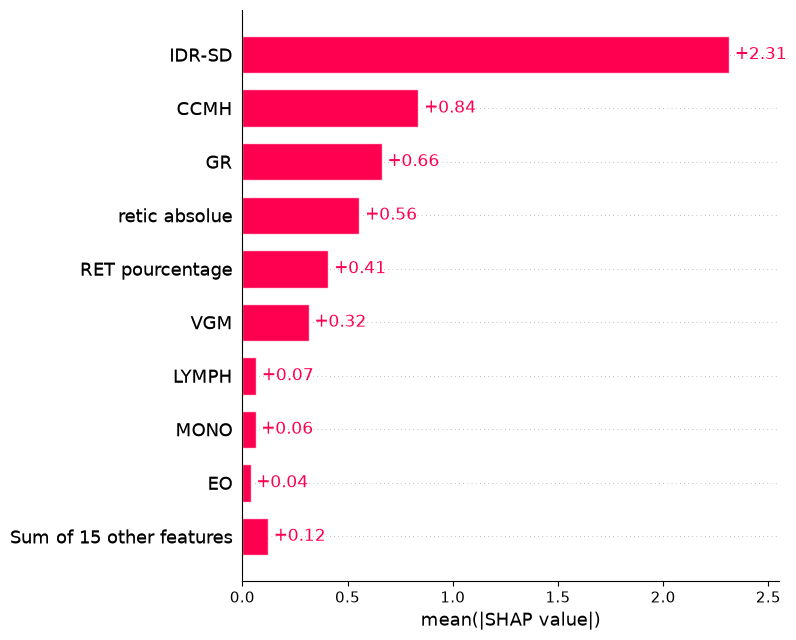

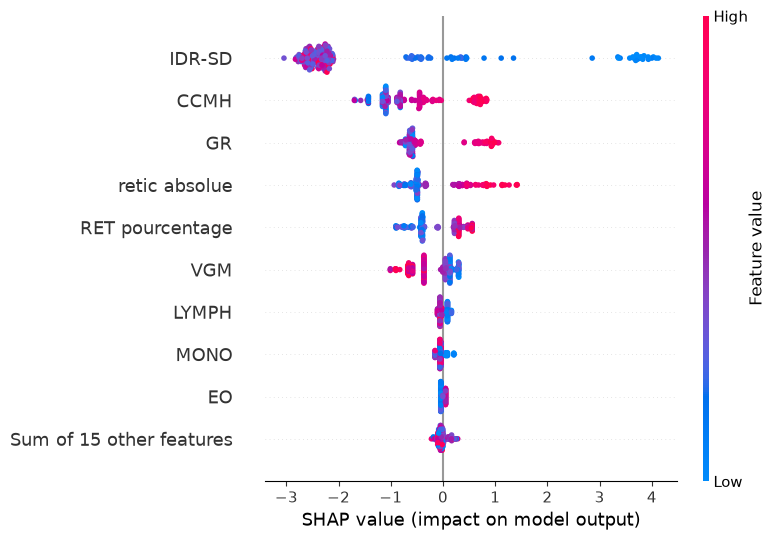

        Feature  Importance
         IDR-SD    2.313523
           CCMH    0.837015
             GR    0.662519
  retic absolue    0.556839
RET pourcentage    0.409277
            VGM    0.315497
          LYMPH    0.065676
           MONO    0.062864
             EO    0.039271
           TCMH    0.032923
            PLQ    0.026262
            HCT    0.011687
            PCT    0.011548
         IDR-CV    0.010786
          P-RGC    0.010537
            IDP    0.009898
            VPM    0.008508
            HBG    0.000000
           NEUT    0.000000
           BASO    0.000000
            IRF    0.000000
            LFR    0.000000
            MFR    0.000000
            HFR    0.000000

Variables retenues pour le score diagnostique (top 3 SHAP) : ['IDR-SD', 'CCMH', 'GR']


In [10]:
# ===== SHAP (feature importance / selection des variables du score) =====
xgb_full = make_xgboost()
xgb_full.fit(X, y)

explainer = shap.Explainer(xgb_full)
shap_values = explainer(X)

shap.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.show()

shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.show()

shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(shap_values.values).mean(axis=0),
}).sort_values("Importance", ascending=False)

print(shap_importance.to_string(index=False))

SCORE_FEATURES = shap_importance["Feature"].head(3).tolist()
print(f"\nVariables retenues pour le score diagnostique (top 3 SHAP) : {SCORE_FEATURES}")

In [11]:
# ===== Construction du score diagnostique final =====
# Split fixe 70% entrainement / 30% validation (demande explicite) : le score final
# doit etre UNE formule fixe entrainee uniquement sur les 70%, jamais evaluee sur les
# donnees qui ont servi a la construire.
X_train70, X_val30, y_train70, y_val30 = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_score_train = X_train70[SCORE_FEATURES]
X_score_val = X_val30[SCORE_FEATURES]

scaler_score = StandardScaler()
X_score_train_scaled = scaler_score.fit_transform(X_score_train)
X_score_val_scaled = scaler_score.transform(X_score_val)

model_score = LogisticRegression(max_iter=1000, random_state=42)
model_score.fit(X_score_train_scaled, y_train70)

coef_std = model_score.coef_[0]
intercept_std = model_score.intercept_[0]

means = scaler_score.mean_
stds = scaler_score.scale_
coef_raw = coef_std / stds
intercept_raw = intercept_std - np.sum(coef_std * means / stds)

terms = " ".join(f"{'+' if c >= 0 else '-'} {abs(c):.4f}*{f}" for f, c in zip(SCORE_FEATURES, coef_raw))
intercept_term = f"{'+' if intercept_raw >= 0 else '-'} {abs(intercept_raw):.4f}"

print("===== ETAPE 1 : logit (z) - combinaison lineaire, valeurs brutes =====")
print(f"z = {terms} {intercept_term}")
print("Attention : z n'est PAS une probabilite (il n'est pas borne entre 0 et 1).")

print("\n===== ETAPE 2 : probabilite BTM (sigmoide de z) =====")
print("P(BTM) = 1 / (1 + exp(-z))")
print("C'est CETTE probabilite qui doit etre comparee au seuil de decision, pas z directement.")

score_std_method = model_score.decision_function(X_score_train_scaled)
score_raw_method = np.dot(X_score_train.values, coef_raw) + intercept_raw
equivalent = np.allclose(score_std_method, score_raw_method, atol=1e-8)
print(f"\n(verification : formule standardisee et formule brute donnent le meme z : {equivalent})")

# ===== Exemple concret (patient "typique" = mediane de chaque groupe) =====
print("\n===== EXEMPLE CONCRET (patient median de chaque groupe) =====")
for group_label in ["IDA", "BTM"]:
    typical = data.loc[data["label"] == group_label, SCORE_FEATURES].median()
    z_typical = float(np.dot(typical.values, coef_raw) + intercept_raw)
    p_typical = 1 / (1 + np.exp(-z_typical))
    values_str = ", ".join(f"{f}={typical[f]:.2f}" for f in SCORE_FEATURES)
    print(f"Patient median {group_label} ({values_str}) : z = {z_typical:.3f} -> P(BTM) = {p_typical:.4f}")

proba_train70 = model_score.predict_proba(X_score_train_scaled)[:, 1]
proba_val30 = model_score.predict_proba(X_score_val_scaled)[:, 1]

===== ETAPE 1 : logit (z) - combinaison lineaire, valeurs brutes =====
z = - 0.2537*IDR-SD + 0.4952*CCMH + 2.3406*GR - 17.6124
Attention : z n'est PAS une probabilite (il n'est pas borne entre 0 et 1).

===== ETAPE 2 : probabilite BTM (sigmoide de z) =====
P(BTM) = 1 / (1 + exp(-z))
C'est CETTE probabilite qui doit etre comparee au seuil de decision, pas z directement.

(verification : formule standardisee et formule brute donnent le meme z : True)

===== EXEMPLE CONCRET (patient median de chaque groupe) =====
Patient median IDA (IDR-SD=46.10, CCMH=29.60, GR=4.29) : z = -4.609 -> P(BTM) = 0.0099
Patient median BTM (IDR-SD=35.90, CCMH=32.30, GR=5.12) : z = 1.259 -> P(BTM) = 0.7788


In [12]:
# ===== Seuil de decision (indice de Youden, calcule sur les 70% d'entrainement) =====
# IMPORTANT : ce seuil s'applique a P(BTM) (la probabilite, etape 2 ci-dessus),
# PAS a z (le logit brut, etape 1) - ce sont deux echelles differentes.
score_threshold = youden_threshold(y_train70, proba_train70)
print(f"Seuil optimal (Youden) sur P(BTM) = {score_threshold:.4f}")
print("(calcule uniquement sur les 70% d'entrainement, puis applique tel quel a la validation)")

Seuil optimal (Youden) sur P(BTM) = 0.1421
(calcule uniquement sur les 70% d'entrainement, puis applique tel quel a la validation)


===== Matrice reel / score, validation (n=65, jamais vus a l'entrainement) =====

          Score : IDA  Score : BTM
Reel IDA           53            4
Reel BTM            0            8

Patients correctement diagnostiques : 61/65 (93.8%)
Sensibilite (BTM detectes) : 100.0%
Specificite (IDA detectes) : 93.0%
AUC : 1.0000 (p-value vs 0.5 : 0.00e+00)

===== Extrait patient par patient (10 premiers, validation) =====

  Diagnostic reel Diagnostic score        P(BTM)
0             BTM              BTM  4.122079e-01
1             IDA              IDA  1.734821e-03
2             IDA              IDA  1.824628e-03
3             IDA              IDA  1.914990e-07
4             IDA              IDA  4.138502e-02
5             IDA              IDA  1.372878e-02
6             IDA              IDA  3.399897e-03
7             IDA              IDA  4.253588e-06
8             IDA              IDA  2.085896e-02
9             IDA              IDA  2.375748e-03


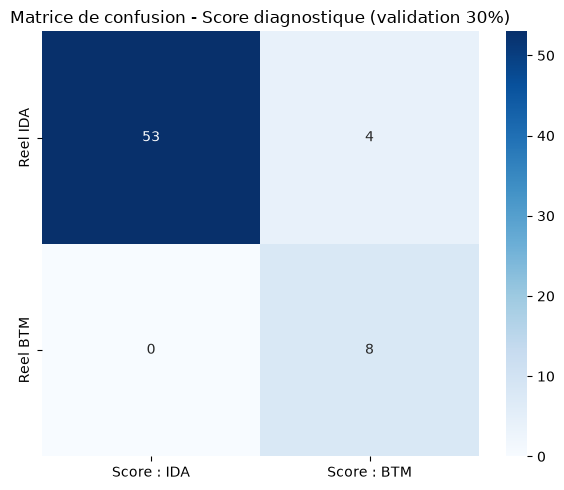

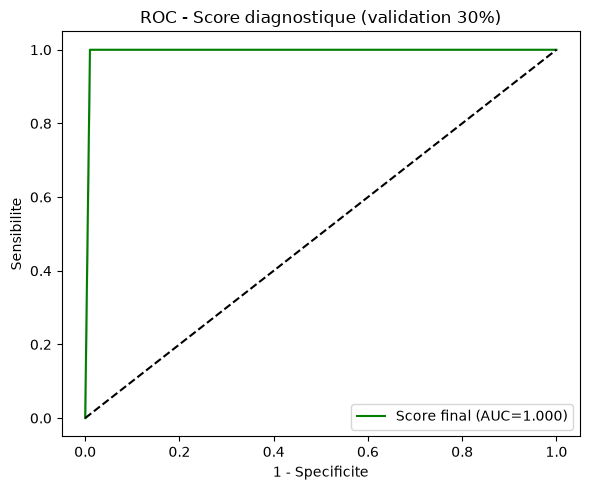

In [13]:
# ===== Validation du score sur les 30% mis de cote (jamais vus a l'entrainement) =====
label_map = {0: "IDA", 1: "BTM"}

y_pred_val30 = (proba_val30 > score_threshold).astype(int)
metrics_score = binary_metrics(y_val30, y_pred_val30, proba_val30)

n1 = int((y_val30 == 1).sum())
n0 = int((y_val30 == 0).sum())
auc_val = metrics_score["auc"]
Q1 = auc_val / (2 - auc_val)
Q2 = 2 * auc_val ** 2 / (1 + auc_val)
se_auc = np.sqrt((auc_val * (1 - auc_val) + (n1 - 1) * (Q1 - auc_val ** 2)
                  + (n0 - 1) * (Q2 - auc_val ** 2)) / (n0 * n1))
if se_auc == 0:
    # AUC parfait (1.0) sur ce split de validation : l'erreur-standard degenere a 0.
    # p-value bornee a une valeur extremement petite plutot que division par zero.
    p_value_score = 0.0
else:
    z = (auc_val - 0.5) / se_auc
    p_value_score = 2 * (1 - norm.cdf(abs(z)))

# ===== Tableau reel / score, patients de validation (jamais vus a l'entrainement) =====
comparison_val = pd.DataFrame({
    "Diagnostic reel": y_val30.map(label_map).values,
    "Diagnostic score": pd.Series(y_pred_val30, index=y_val30.index).map(label_map).values,
    "P(BTM)": proba_val30,
})

cm_score = confusion_matrix(y_val30, y_pred_val30)
cm_score_df = pd.DataFrame(cm_score, index=["Reel IDA", "Reel BTM"], columns=["Score : IDA", "Score : BTM"])
print("===== Matrice reel / score, validation (n={}, jamais vus a l'entrainement) =====\n".format(len(y_val30)))
print(cm_score_df)

n_correct_val = int((y_pred_val30 == y_val30.values).sum())
print(f"\nPatients correctement diagnostiques : {n_correct_val}/{len(y_val30)} ({metrics_score['accuracy']*100:.1f}%)")
print(f"Sensibilite (BTM detectes) : {metrics_score['sensitivity']*100:.1f}%")
print(f"Specificite (IDA detectes) : {metrics_score['specificity']*100:.1f}%")
print(f"AUC : {auc_val:.4f} (p-value vs 0.5 : {p_value_score:.2e})")

print("\n===== Extrait patient par patient (10 premiers, validation) =====\n")
print(comparison_val.head(10).to_string())

plt.figure(figsize=(6, 5))
sns.heatmap(cm_score_df, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion - Score diagnostique (validation 30%)")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_val30, proba_val30)
n_boot = 1000
rng = np.random.RandomState(42)
mean_fpr = np.linspace(0, 1, 100)
tprs = []
y_val30_arr = y_val30.values
for _ in range(n_boot):
    idx = rng.randint(0, len(y_val30_arr), len(y_val30_arr))
    if len(np.unique(y_val30_arr[idx])) < 2:
        continue
    f, t, _ = roc_curve(y_val30_arr[idx], proba_val30[idx])
    ti = np.interp(mean_fpr, f, t)
    ti[0] = 0.0
    tprs.append(ti)
mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)
upper = np.minimum(mean_tpr + 1.96 * std_tpr, 1)
lower = np.maximum(mean_tpr - 1.96 * std_tpr, 0)

plt.figure(figsize=(6, 5))
plt.plot(mean_fpr, mean_tpr, color="green", label=f"Score final (AUC={auc_val:.3f})")
plt.fill_between(mean_fpr, lower, upper, color="gray", alpha=0.3)
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("1 - Specificite")
plt.ylabel("Sensibilite")
plt.title("ROC - Score diagnostique (validation 30%)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Robustesse du score sur 50 splits 70/30 differents (memes 3 variables, seuil recalcule a chaque fois) :

       accuracy  sensitivity  specificity      auc
count   50.0000      50.0000      50.0000  50.0000
mean     0.9474       0.9300       0.9498   0.9918
std      0.0229       0.1015       0.0344   0.0081
min      0.8923       0.7500       0.8772   0.9737
25%      0.9385       0.8750       0.9298   0.9868
50%      0.9538       1.0000       0.9474   0.9934
75%      0.9692       1.0000       0.9825   1.0000
max      0.9846       1.0000       1.0000   1.0000

AUC >= 0.999 dans 14/50 splits
Seed officielle (42) : AUC = 1.0000


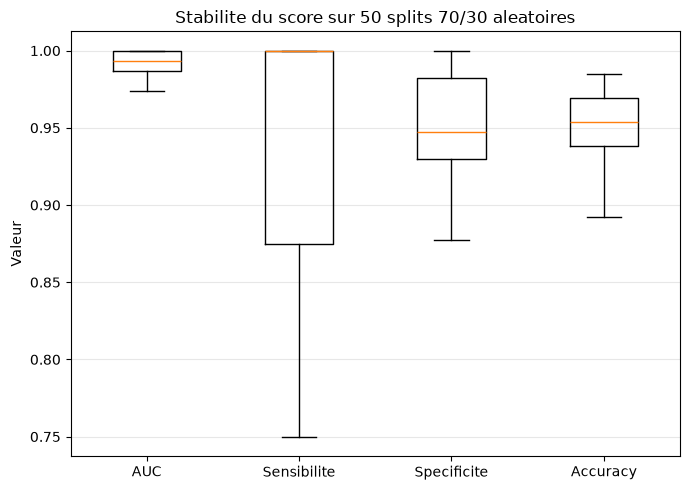

In [14]:
# ===== Robustesse du score : le split 70/30 officiel est-il un coup de chance ? =====
# La formule officielle du score (ci-dessus) reste celle entrainee avec
# random_state=42, c'est LA formule a publier. Ici, on repete uniquement le
# processus entrainement(70%)/validation(30%) avec plusieurs graines aleatoires
# differentes, pour voir si l'AUC=1.000 observe est stable ou s'il depend d'un
# decoupage particulierement favorable (le groupe BTM est petit : 27 patients au
# total, ~8 dans chaque validation de 30%, donc un seul split peut etre optimiste).
N_ROBUSTNESS = 50
robustness_rows = []

for seed in range(N_ROBUSTNESS):
    Xr_train, Xr_val, yr_train, yr_val = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=seed
    )

    Xr_score_train = Xr_train[SCORE_FEATURES]
    Xr_score_val = Xr_val[SCORE_FEATURES]

    scaler_r = StandardScaler()
    Xr_train_scaled = scaler_r.fit_transform(Xr_score_train)
    Xr_val_scaled = scaler_r.transform(Xr_score_val)

    model_r = LogisticRegression(max_iter=1000, random_state=42)
    model_r.fit(Xr_train_scaled, yr_train)

    proba_r_train = model_r.predict_proba(Xr_train_scaled)[:, 1]
    proba_r_val = model_r.predict_proba(Xr_val_scaled)[:, 1]

    thr_r = youden_threshold(yr_train, proba_r_train)
    pred_r_val = (proba_r_val > thr_r).astype(int)

    m = binary_metrics(yr_val, pred_r_val, proba_r_val)
    m["seed"] = seed
    robustness_rows.append(m)

robustness_df = pd.DataFrame(robustness_rows)

print(f"Robustesse du score sur {N_ROBUSTNESS} splits 70/30 differents (memes 3 variables, seuil recalcule a chaque fois) :\n")
print(robustness_df[["accuracy", "sensitivity", "specificity", "auc"]].describe().round(4).to_string())

n_perfect_auc = (robustness_df["auc"] >= 0.999).sum()
print(f"\nAUC >= 0.999 dans {n_perfect_auc}/{N_ROBUSTNESS} splits")
print(f"Seed officielle (42) : AUC = {robustness_df.loc[robustness_df['seed'] == 42, 'auc'].values[0]:.4f}")

plt.figure(figsize=(7, 5))
plt.boxplot(
    [robustness_df["auc"], robustness_df["sensitivity"], robustness_df["specificity"], robustness_df["accuracy"]],
    tick_labels=["AUC", "Sensibilite", "Specificite", "Accuracy"],
)
plt.title(f"Stabilite du score sur {N_ROBUSTNESS} splits 70/30 aleatoires")
plt.ylabel("Valeur")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [15]:
# ===== Tableau recapitulatif unique (base de la heatmap) =====
# ATTENTION methodologie : les lignes XGBoost/Elastic Net/indices proviennent de la
# boucle Monte Carlo (moyenne sur 1000 splits 80/20 ; seuil = cutoff officiel pour
# les indices, seuil de Youden par fold pour les modeles ML) ; la ligne "Score
# diagnostique" provient d'un split unique 70/30 (construit sur 70%, valide sur 30%
# jamais vus). Toutes les lignes ont desormais les memes metriques, ce qui permet
# une comparaison directe sur la heatmap ci-dessous.
summary_rows = []
nir = max(y.mean(), 1 - y.mean())

for label in ["XGBoost", "Elastic Net"]:
    m = model_metrics[label]
    acc_mean, acc_lo, acc_hi = summarize(m, "accuracy")
    auc_mean, auc_lo, auc_hi = summarize(m, "auc")
    p_val = binomtest(int(acc_mean * len(y)), len(y), nir, alternative="greater").pvalue
    summary_rows.append({
        "Modele": label,
        "Accuracy": acc_mean,
        "Sensibilite": np.mean([x["sensitivity"] for x in m]),
        "Specificite": np.mean([x["specificity"] for x in m]),
        "Precision": np.mean([x["precision"] for x in m]),
        "NPV": np.mean([x["npv"] for x in m]),
        "F1": np.mean([x["f1"] for x in m]),
        "AUC": auc_mean, "AUC_low": auc_lo, "AUC_high": auc_hi,
        "CER": 1 - acc_mean, "p-value": p_val,
    })

for name in INDEX_DEFINITIONS:
    m = index_metrics[name]
    acc_mean, acc_lo, acc_hi = summarize(m, "accuracy")
    auc_mean, auc_lo, auc_hi = summarize(m, "auc")
    p_val = binomtest(int(acc_mean * len(y)), len(y), nir, alternative="greater").pvalue
    summary_rows.append({
        "Modele": name,
        "Accuracy": acc_mean,
        "Sensibilite": np.mean([x["sensitivity"] for x in m]),
        "Specificite": np.mean([x["specificity"] for x in m]),
        "Precision": np.mean([x["precision"] for x in m]),
        "NPV": np.mean([x["npv"] for x in m]),
        "F1": np.mean([x["f1"] for x in m]),
        "AUC": auc_mean, "AUC_low": auc_lo, "AUC_high": auc_hi,
        "CER": 1 - acc_mean, "p-value": p_val,
    })

summary_rows.append({
    "Modele": "Score diagnostique (validation 30%)",
    "Accuracy": metrics_score["accuracy"], "Sensibilite": metrics_score["sensitivity"],
    "Specificite": metrics_score["specificity"], "Precision": metrics_score["precision"],
    "NPV": metrics_score["npv"], "F1": metrics_score["f1"], "AUC": metrics_score["auc"],
    "AUC_low": np.nan, "AUC_high": np.nan, "CER": 1 - metrics_score["accuracy"],
    "p-value": p_value_score,
})

summary_df = pd.DataFrame(summary_rows).sort_values("AUC", ascending=False).reset_index(drop=True)

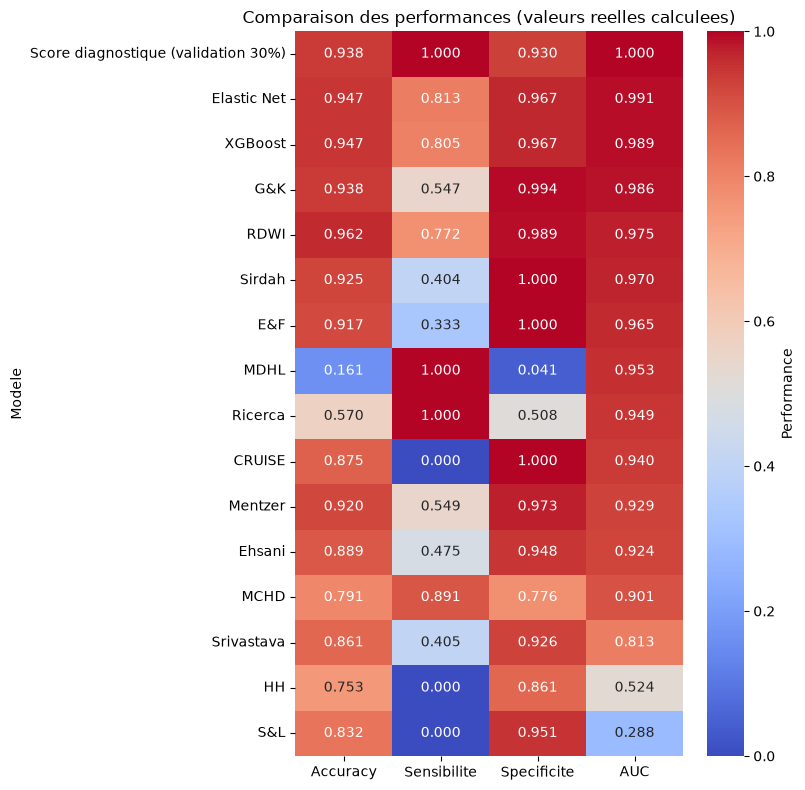

In [16]:
# ===== Heatmap comparative (regeneree a partir des vraies valeurs calculees) =====
heatmap_df = summary_df.set_index("Modele")[["Accuracy", "Sensibilite", "Specificite", "AUC"]].dropna()

plt.figure(figsize=(8, max(4, 0.5 * len(heatmap_df))))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="coolwarm", vmin=0, vmax=1,
            cbar_kws={"label": "Performance"})
plt.title("Comparaison des performances (valeurs reelles calculees)")
plt.tight_layout()
plt.show()